# Product-Inventory Problem Test

In [1]:
import lropt

In [2]:
import cvxpy as cp

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as npr
import numpy.testing as npt
import scipy as sc
import torch
from sklearn.model_selection import train_test_split

In [3]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 2 # number of time periods

# family parameter (production costs)
dist = [1-0.5*np.sin(np.pi*(t-1)/12) for t in range(1, n+1)]
sig = np.random.rand(n, n)
sig = np.dot(sig, sig.T) # to ensure symmetric positive definiteness
y_data = np.random.multivariate_normal(dist, sig, 10)
y_data = np.tile(y_data, (10, 1))

In [4]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    theta = 0.025
    d_hat = [1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+1)] # nominal demand
    d_train = d_hat * np.random.uniform(1-theta, 1+theta, (N, n))
    return d_hat, d_train

In [5]:
# initialize problem
P = np.full(n, 567) # max production capacity at each time period
Q = 1100 # max production capacity for all periods
V_min = 500 # minimum inventory
V_max = 2000 # maximum inventory
v_1 = 2000 # initial inventory
d_hat, data = gen_demand_intro(100, seed=15) # demand
print(d_hat)

[1000.0, 1129.4095225512604]


## Problem with Known Demand ("Ideal" Case)

In [6]:
print(dist) # costs

[1.0, 0.8705904774487396]


In [13]:
opt_objectives = []
opt_x = []

# 100 simulations (demands drawn at random, according to uniform dist.)
for demand in data:
    x = cp.Variable(n)
    u = demand
    objective = cp.Minimize(x @ dist)
    constraints = [cp.sum(x) <= Q, x >=0, x<= P]
    for t in range(n):
        b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
        constraints.append(x @ b - u @ b >= V_min - v_1)
        constraints.append(x @ b - u @ b <= V_max - v_1)
    
    prob = cp.Problem(objective, constraints)
    prob.solve()
    opt_objectives.append(prob.value)
    opt_x.append(x.value)

In [14]:
print(data[0]) # demand
print(opt_objectives[0]) # objective
print(opt_x[0]) # optimal x

[1017.44088486 1111.27662255]
555.3423083005029
[ 61.71750768 566.9999999 ]


In [15]:
print("Production Cost Mean: ", np.mean(opt_objectives))
print("Production Cost Std: ", np.std(opt_objectives))

Production Cost Mean:  553.2615582619177
Production Cost Std:  22.31580301377204


Above results have been checked (matches intuitive optimal solutions).

## Problem with Uncertain Demand (AARC)

In [16]:
d_hat

[1000.0, 1129.4095225512604]

In [125]:
# used to check accuracy of below aarc method
def aarc_online_manual(theta):
    pi_0 = cp.Variable(n)
    q_1 = cp.Variable()
    q_2 = cp.Variable()
    q_3 = cp.Variable()
    
    obj = pi_0 @ dist + (1 + theta) * (dist[0]*q_1*d_hat[0] + dist[1]*q_2*d_hat[0] + dist[1]*q_3*d_hat[1])
    objective = cp.Minimize(obj)

    constraints = []
    c1 = cp.sum(pi_0) + (1 + theta) * (q_1*d_hat[0] + q_2*d_hat[0] + q_3*d_hat[1])
    constraints.append(c1 <= Q)
    constraints.append(c1 - (1 - theta) * (d_hat[0] + d_hat[1]) <= V_max - v_1)
    constraints.append(c1 - (1 + theta) * (d_hat[0] + d_hat[1]) >= V_min - v_1)
    constraints.append(pi_0[0] - (1 - theta) * d_hat[0] <= V_max - v_1)
    constraints.append(pi_0[0] - (1 + theta) * d_hat[0] >= V_min - v_1)
    constraints.append(pi_0[0] + (1 + theta) * q_1 * d_hat[0] <= P[0])
    constraints.append(pi_0[0] + (1 - theta) * q_1 * d_hat[0] >= 0)
    constraints.append(pi_0[1] + (1 + theta) * (q_2 * d_hat[0] + q_3 * d_hat[1]) <= P[1])
    constraints.append(pi_0[1] + (1 - theta) * (q_2 * d_hat[0] + q_3 * d_hat[1]) >= 0)

    prob = cp.Problem(objective, constraints)
    print(prob.solve())

In [126]:
aarc_online_manual(theta = 0.01) # richest "on-line" information basis

577.3284185085504


In [127]:
# k is the information lag
def aarc(theta, k):
    I = 1
    pi_0 = cp.Variable((I, n))
    phi = cp.Variable((I, n*n))

    obj = pi_0 @ dist
    constraints = []
    c1 = cp.sum(pi_0, axis = 1)
    c2 = []
    for t in range(n):
        A = np.zeros((n, n))
        if (t - k >= 0):
            A[:t-k, :t-k] = np.identity(t - k)
            
        obj += (1 + theta) * (dist[t] * phi[:, n*t:n*(t+1)] @ A @ d_hat)
        c1 += (1 + theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat)
        constraints.append(pi_0[:, t] + (1 + theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat) <= P[t])
        constraints.append(pi_0[:, t] + (1 - theta) * (phi[:, n*t:n*(t+1)] @ A @ d_hat) >= 0)
        c2.append(np.ones(I) @ phi[:, n*t:n*(t+1)] @ A @ d_hat)
    
    objective = cp.Minimize(obj)
    constraints.append(c1 <= Q)
        
    for t in range(n):
        b = np.concatenate((np.ones(t + 1), np.zeros(n - t - 1)))
        constraints.append((np.ones(I) @ pi_0) @ b - (1 - theta) * (b.T @ d_hat) + (1 - theta) * (c2 @ b) <= V_max - v_1)
        constraints.append((np.ones(I) @ pi_0) @ b - (1 + theta) * (b.T @ d_hat) + (1 + theta) * (c2 @ b) >= V_min - v_1)

    prob = cp.Problem(objective, constraints)
    print(prob.solve())

In [128]:
aarc(theta = 0.01, k = 0) # richest "on-line" information basis

577.3284185064549


In [132]:
aarc(theta = 0.025, k = 1) # standard information basis (knowing complete past demands)

609.2695614306052


In [134]:
# ideal case
x = cp.Variable(n)
objective = cp.Minimize(x @ dist)
constraints = [cp.sum(x) <= Q, x >=0, x<= P]
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(x @ b - d_hat @ b >= V_min - v_1)
    constraints.append(x @ b - d_hat @ b <= V_max - v_1)
    
prob = cp.Problem(objective, constraints)
prob.solve()

556.0343234585173

As expected, compared to the ideal case, the ARO optimal objective (609.27) is still above the ideal production cost (556.03), where there is no uncertainty in the demand.

## Using LROPT

In [81]:
# y_data = np.array([[1, 0.87]])
# y_data = np.tile(y_data, (100, 1))

In [82]:
y = lropt.Parameter(n, data = y_data) 
# y = lropt.Parameter(n, data = np.array([dist])) # only looking at one cost case
u = lropt.UncertainParameter(n, uncertainty_set=lropt.Box(data=data))
x = cp.Variable(n)
objective = cp.Minimize(x @ y)
constraints = [cp.sum(x) <= Q, x >= 0, x <= P]

# combine uncertain constraints into one
# temp_constr1 = np.array([[-1, 0],[1, 0], [-1, -1], [1, 1]])
# temp_constr2 = np.array([[1, 0],[-1, 0], [1, 1], [-1, -1]])
# temp_constants = np.array([1500, 0, 1500, 0])
# constraints.append(temp_constr1 @ x + temp_constr2 @ u  <= temp_constants)
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(x @ b - u @ b >= V_min - v_1)
    constraints.append(x @ b - u @ b <= V_max - v_1)

prob = lropt.RobustProblem(objective, constraints)

In [83]:
test_p = 0.1
s = 15
train, _ = train_test_split(data, test_size=int(data.shape[0]*test_p), random_state=s)

initn = sc.linalg.sqrtm(np.cov(train.T))
np.random.seed(15)
# initn = np.random.rand(n, n) + 0.1*init + 0.5*np.eye(n)
init_bvaln = np.mean(train, axis=0)

In [84]:
print(initn)
print(init_bvaln)

[[15.59402035 -0.05705167]
 [-0.05705167 15.43788718]]
[ 999.75585515 1126.70662834]


### Original LROPT

In [85]:
# Train A and b
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=2, position = True)

run 0: test value N/A, violations N/A:   0%|            | 0/100 [00:00<?, ?it/s]/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:848: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robus

In [64]:
# Train A and b
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=2, position = True)

run 0: test value N/A, violations N/A:   0%|            | 0/100 [00:00<?, ?it/s]/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:848: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robus

In [86]:
results_df = result.df
df_test = result.df_test

In [87]:
results_df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",453.959092,453.93909,"[0.0, 0.0, 0.5222222208976746, 0.0]",0.01,0.130556,"(0.7930387253795503,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(2.0674471581405247,)","([[tensor(1.0330, dtype=torch.float64), tensor..."
1,"(1,)",453.947527,453.931524,"[0.0, 0.0, 0.5222222208976746, 0.0]",0.008,0.130556,"(0.7912897126492471,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(2.065811330366073,)","([[tensor(1.0322, dtype=torch.float64), tensor..."
2,"(2,)",453.926709,453.917909,"[0.0, 0.0, 0.5222222208976746, 0.0]",0.004399,0.130556,"(0.7881467516605914,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(2.059522704356069,)","([[tensor(1.0305, dtype=torch.float64), tensor..."
3,"(3,)",453.898514,453.89948,"[0.0, 0.0, 0.5222222208976746, 0.0]",-0.000483,0.130556,"(0.7838999715954564,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(2.063698544245416,)","([[tensor(1.0318, dtype=torch.float64), tensor..."
4,"(4,)",453.864405,453.877183,"[0.0, 0.0, 0.5222222208976746, 0.0]",-0.006388,0.130556,"(0.7787745752617474,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(2.0599887779516735,)","([[tensor(1.0300, dtype=torch.float64), tensor..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",449.37546,451.14552,"[0.0, 0.0, 0.5333333611488342, 0.0]",-0.892856,0.133333,"(0.41054011536362384,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(2.0664746705846206,)","([[tensor(1.0312, dtype=torch.float64), tensor..."
96,"(96,)",449.340948,451.13032,"[0.0, 0.0, 0.5333333611488342, 0.0]",-0.902686,0.133333,"(0.4105264087977933,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(2.060399185175765,)","([[tensor(-1.0354, dtype=torch.float64), tenso..."
97,"(97,)",449.311347,451.120021,"[0.0, 0.0, 0.5333333611488342, 0.0]",-0.912515,0.133333,"(0.4105180393207616,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(2.0491862267020973,)","([[tensor(-1.0214, dtype=torch.float64), tenso..."
98,"(98,)",449.279747,451.107717,"[0.0, 0.0, 0.5333333611488342, 0.0]",-0.922342,0.133333,"(0.4105112262993559,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(2.0492881750994725,)","([[tensor(1.0116, dtype=torch.float64), tensor..."


In [96]:
result.var_values[0] # x

tensor([[ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [567.0000,  58.4196],
        [567.0000,  58.4196],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [567.0000,  58.4196],
        [567.0000,  58.4196],
        [ 58.4196, 567.0000],
        [567.0000,  58.4196],
        [567.0000,  58.4196],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [567.0000,  58.4196],
        [567.0000,  58.4196],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [567.0000,  58.4196],
        [ 58.4196, 567.0000],
        [ 58.4196, 567.0000],
        [ 

In [97]:
result.obj

451.94157104999357

### Modified LROPT (Fixed initial values) - CONSTANT

In [264]:
# Train A and b
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = True, random_init=True, num_random_init=2, position = True)


run 1: test value 555.94, violations 0.4: 100%|██████████| 100/100 [00:01<00:00, 71.30it/s]


In [265]:
result.var_values

(tensor([[ 60.5682, 567.0000]], dtype=torch.float64, requires_grad=True),)

In [266]:
result.weights

[tensor([[1.3552, 0.1789],
         [0.0544, 0.8680]], dtype=torch.float64),
 tensor([-1556.0293, -1032.0964], dtype=torch.float64)]

In [267]:
result.obj

554.1929994000086

In [268]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",554.213001,554.192999,0.527778,0.01,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([-0.0005001, -0.0005001, -0.0005001, -0.00050...","(tensor(2.0004),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."
1,"(1,)",554.209003,554.192999,0.569444,0.008,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."
2,"(2,)",554.201799,554.192999,0.513889,0.004399,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."
3,"(3,)",554.192034,554.192999,0.555556,-0.000483,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."
4,"(4,)",554.180221,554.192999,0.583333,-0.006388,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",552.422939,554.192999,0.569444,-0.892856,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."
96,"(96,)",552.403628,554.192999,0.5,-0.902686,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."
97,"(97,)",552.384325,554.192999,0.5,-0.912515,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."
98,"(98,)",552.36503,554.192999,0.541667,-0.922342,"(1.6202073413134954,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(1492.779549862193,)","([[tensor([-611.4029, -689.2833], dtype=torch...."


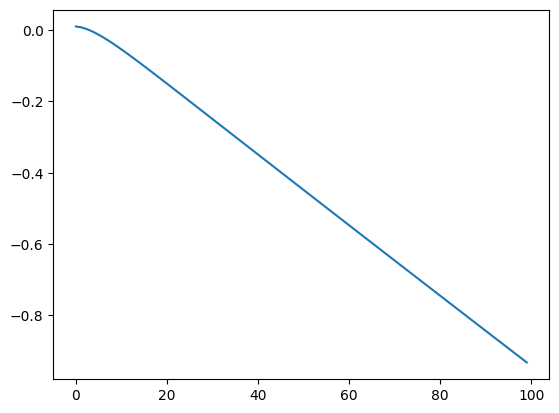

In [269]:
plt.plot(result.df["Violations_train"])

### Random Initialization - CONSTANT

In [242]:
# Train A and b
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = True, random_init=True, num_random_init=2, position = True)

HERE_A tensor([[1.3552, 0.1789],
        [0.0544, 0.8680]], dtype=torch.float64, requires_grad=True) HERE_B tensor([-1556.0293, -1032.0964], dtype=torch.float64, requires_grad=True)
HERE_A tensor([[0.2333, 0.5232],
        [0.5507, 0.0556]], dtype=torch.float64, requires_grad=True) HERE_B tensor([-822.6857, -613.2141], dtype=torch.float64, requires_grad=True)



run 1: test value 0.0, violations 1.0: 100%|██████████| 100/100 [00:01<00:00, 93.95it/s]


In [243]:
result.var_values

(tensor([[1.3359e-09, 8.5398e-10]], dtype=torch.float64, requires_grad=True),)

In [244]:
result.weights

[tensor([[ 1.5410, -0.2934],
         [-2.1788,  0.5684]], dtype=torch.float64),
 tensor([-1.0845, -1.3986], dtype=torch.float64)]

In [245]:
result.obj

2.0793254505339805e-09

In [248]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",0.020002,0.0,1.0,0.01,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([-0.0005001, -0.0005001, -0.0005001, -0.00050...","(tensor(2.0004),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
1,"(1,)",0.016004,0.0,1.0,0.008,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
2,"(2,)",0.008799,0.0,1.0,0.004399,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
3,"(3,)",-0.000966,0.0,1.0,-0.000483,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
4,"(4,)",-0.012778,0.0,1.0,-0.006388,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",-1.770061,0.0,1.0,-0.892856,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
96,"(96,)",-1.789372,0.0,1.0,-0.902686,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
97,"(97,)",-1.808674,0.0,1.0,-0.912515,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."
98,"(98,)",-1.82797,0.0,1.0,-0.922342,"(2.7442679928882887,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(0.02279406852716879,)","([[tensor([-0.0043, -0.0184], dtype=torch.floa..."


### Modified LROPT - LINEAR

In [313]:
# Train A and b
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD", predictor="LINEAR",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = True, random_init=True, num_random_init=2, position = True)


run 0: test value 812.574, violations 0.0: 100%|██████████| 100/100 [00:01<00:00, 91.84it/s]


In [314]:
result.obj

489.19751876858203

In [316]:
result.var_values

(tensor([[2.2504e-07, 5.6191e+02]], dtype=torch.float64, requires_grad=True),)

In [317]:
result.weights

[tensor([[0.2333, 0.5232],
         [0.5507, 0.0556],
         [0.2333, 0.5232],
         [0.5507, 0.0556]], dtype=torch.float64),
 tensor([[-822.6857, -822.6857],
         [-613.2141, -613.2141]], dtype=torch.float64),
 tensor([ 1.5410, -0.2934, -2.1788,  0.5684], dtype=torch.float64),
 tensor([-1.0845, -1.3986], dtype=torch.float64)]

In [320]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",489.217521,489.197519,1.0,0.01,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([-0.0005001, -0.0005001, -0.0005001, -0.00050...","(tensor(2.0004),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."
1,"(1,)",489.213522,489.197519,1.0,0.008,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."
2,"(2,)",489.206318,489.197519,1.0,0.004399,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."
3,"(3,)",489.196553,489.197519,1.0,-0.000483,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."
4,"(4,)",489.18474,489.197519,1.0,-0.006388,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",487.427458,489.197519,1.0,-0.892856,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."
96,"(96,)",487.408147,489.197519,1.0,-0.902686,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."
97,"(97,)",487.388844,489.197519,1.0,-0.912515,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."
98,"(98,)",487.369549,489.197519,1.0,-0.922342,"(2.940846103712797,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(1359.669271923734,)","([[tensor([ -316.4939, -1062.2376], dtype=torc..."


# Time as Context
"standard information basis" - past is known, present and future unknown

In [19]:
# # time 1 --> [0, 0], time 2 --> [1, 0] (1 at time when demand is known - at all t-1 elements)
# y_data = np.array([[0,0], [1,0]])
# y_data = np.tile(y_data, (50, 1))

# y = lropt.Parameter(n, data = y_data) 
# u = lropt.UncertainParameter(n, uncertainty_set=lropt.Box(data=data))
# x = cp.Variable(n)
# objective = cp.Minimize(x @ cost)
# constraints = [cp.sum(x) <= Q, x >= 0, x <= P]
# for t in range(n):
#     b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
#     constraints.append(x @ b - u @ (b-y) - d_hat @ y >= V_min - V_1) # need ReLU(b-y) for time periods t=3,4,etc.
#     constraints.append(x @ b - u @ (b-y) - d_hat @ y <= V_max - V_1) # need ReLU(b-y) for time periods t=3,4,etc.

# prob = lropt.RobustProblem(objective, constraints)

In [98]:
import lropt
import cvxpy as cp

import matplotlib.pyplot as plt
import numpy as np
import numpy.random as npr
import numpy.testing as npt
import scipy as sc
import torch
from sklearn.model_selection import train_test_split

In [99]:
seed = 15
np.random.seed(seed)
kappa = -0.01
n = 2 # number of time periods

In [100]:
# uncertainty distribution
def gen_demand_intro(N, seed):
    np.random.seed(seed)
    theta = 0.025
    d_hat = [1000*(1+0.5*np.sin(np.pi*(t-1)/12)) for t in range(1, n+2)] # nominal demand (t = 1, 2, 3)
    d_train_temp = d_hat * np.random.uniform(1-theta, 1+theta, (N, n+1))

    d_train = []
    for i, row in enumerate(d_train_temp):
        if i%2 == 0:
            d_train.append(row[-2:]) # get demand at times t = 2,3 when y = 2
        else:
            d_train.append(row[:2]) # get demand at times t = 1,2 when y = 1
    d_train = np.array(d_train)
    
    return d_hat, d_train

In [101]:
# initialize problem
cost = np.array([1, 0.87, 1.5])
P = np.full(n + 1, 567) # max production capacity at each time period
Q = 1100 # max production capacity for all periods
V_min = 500 # minimum inventory
V_max = 2000 # maximum inventory
V_1 = 2000 # initial inventory
d_hat, data = gen_demand_intro(100, seed=15) # demand
print(d_hat)

[1000.0, 1129.4095225512604, 1250.0]


In [102]:
# simulating inventories at each time beforehand (no uncertainty in demand)
x = cp.Variable(n + 1)
objective = cp.Minimize(x @ cost)
constraints = [cp.sum(x) <= Q, x >=0, x<= P]
for t in range(n):
    b = np.concatenate((np.ones(t+1), np.zeros(n-t)))
    constraints.append(x @ b - d_hat @ b >= V_min - V_1)
    constraints.append(x @ b - d_hat @ b <= V_max - V_1)

prob = cp.Problem(objective, constraints)
prob.solve()
opt_obj = prob.value
opt_prod = x.value
x.value

array([6.2409523e+01, 5.6700000e+02, 8.3133694e-09])

In [105]:
inventories = np.zeros(n)
inventories[0] = V_1
for t in range(1, n):
    inventories[t] = inventories[t-1] + opt_prod[t-1] - d_hat[t-1]

y_data = np.array([[t, inventories[t-1]] for t in range(1, n + 1)])
y_data = np.tile(y_data, (50, 1))

In [ ]:
# t = 0
# 2000 + p1 - d1 --> x @ (1, 0, 0)
# 1062 + p2 - d2 --> x @ (0, 1, 0)

# t = 1
# 2000 + p1 + p2 - d1 - d2 --> x @ (1, 1, 0)
# 1062 + p2 + p3 - d2 - d3 --> x @ (0, 1, 1)

In [129]:
y = lropt.Parameter(n, data = y_data) 
u = lropt.UncertainParameter(n, uncertainty_set=lropt.Box(data=data))
x = cp.Variable(n)
objective = cp.Minimize(x @ cost[:2])
constraints = [cp.sum(x) <= Q, x >= 0, x <= P[:2]]

for t in range(n): # for n = 2: one constraint for time t, one constrant for time t and t+1
    b = np.concatenate((np.ones(t+1), np.zeros(n-t-1)))
    constraints.append(y @ np.array([0, 1]) + x @ b - u @ b >= V_min)
    constraints.append(y @ np.array([0, 1]) + x @ b - u @ b <= V_max)

prob = lropt.RobustProblem(objective, constraints)

In [130]:
test_p = 0.1
s = 15
train, _ = train_test_split(data, test_size=int(data.shape[0]*test_p), random_state=s)

initn = sc.linalg.sqrtm(np.cov(train.T))
np.random.seed(15)
init_bvaln = np.mean(train, axis=0)

In [131]:
# Train A and b - constant predictor
result = prob.train(lr=0.001, num_iter=100, momentum=0.8,
                    optimizer="SGD", predictor = "CONSTANT",
                    seed=s, init_A=initn, init_b=init_bvaln,
                    init_lam=0.5, init_mu=0.01,
                    mu_multiplier=1.001, init_alpha=0., test_percentage=test_p, kappa=kappa,
                    parallel = False, random_init=True, num_random_init=1, position = True, save_history = True)

run 0: test value N/A, violations N/A:   0%|            | 0/100 [00:00<?, ?it/s]/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robust_problem.py:848: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_tchs.append(torch.tensor(
/Users/annieliang/anaconda3/envs/lropt/lib/python3.11/site-packages/threadpoolctl.py:1010: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/annieliang/Desktop/Spring2024/Thesis/lropt/lropt/robus

In [132]:
result.df

,step,Lagrangian_val,Train_val,Probability_violations_train,Violations_train,Avg_prob_train,A_norm,lam_list,mu,alpha,slack,alphagrad,dfnorm,gradnorm
0,"(0,)",432.53914,432.519138,"[0.5, 0.0, 0.5, 0.0]",0.01,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(0.0,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.0368618454941477,)","([[tensor([0.0029, 0.0019], dtype=torch.float6..."
1,"(1,)",432.535141,432.519138,"[0.5, 0.0, 0.5, 0.0]",0.008,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.0020004000980407,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0007),)","(0.0368618454941477,)","([[tensor([-4.8578e-13, -1.4618e-12], dtype=to..."
2,"(2,)",432.527937,432.519138,"[0.5, 0.0, 0.5, 0.0]",0.004399,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.00560144055634737,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0006),)","(0.0368618454941477,)","([[tensor([0.0029, 0.0019], dtype=torch.float6..."
3,"(3,)",432.518172,432.519138,"[0.5, 0.0, 0.5, 0.0]",-0.000483,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.010482849553227425,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0004),)","(0.0368618454941477,)","([[tensor([-4.8578e-13, -1.4618e-12], dtype=to..."
4,"(4,)",432.506359,432.519138,"[0.5, 0.0, 0.5, 0.0]",-0.006388,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01,"(-0.016388356685638428,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(2.0001),)","(0.0368618454941477,)","([[tensor([0.0029, 0.0019], dtype=torch.float6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,"(95,)",430.749077,432.519138,"[0.5, 0.0, 0.5, 0.0]",-0.892856,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9028556942939758,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9645),)","(0.036861845494147706,)","([[tensor([-4.8578e-13, -1.4618e-12], dtype=to..."
96,"(96,)",430.729766,432.519138,"[0.5, 0.0, 0.5, 0.0]",-0.902686,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.912686288356781,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9641),)","(0.0368618454941477,)","([[tensor([0.0029, 0.0019], dtype=torch.float6..."
97,"(97,)",430.710463,432.519138,"[0.5, 0.0, 0.5, 0.0]",-0.912515,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9225149154663086,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9638),)","(0.0368618454941477,)","([[tensor([-4.8578e-13, -1.4618e-12], dtype=to..."
98,"(98,)",430.691168,432.519138,"[0.5, 0.0, 0.5, 0.0]",-0.922342,0.25,"(891.8447218571878,)","([0.5001, 0.5001, 0.5001, 0.5001],)",0.01004,"(-0.9323415756225586,)","([0.0, 0.0, 0.0, 0.0],)","(tensor(1.9634),)","(0.0368618454941477,)","([[tensor([-4.8578e-13, -1.4618e-12], dtype=to..."


In [133]:
A_iters, b_iters = result.uncset_iters # A and b at each iteration
print(A_iters[-1][0])
print(b_iters[-1][0])

[[57.02632999 38.03175882]
 [38.03175882 51.89221282]]
[1064.97673054 1188.78948393]


In [136]:
result.weights

[tensor([[57.0263, 38.0318],
         [38.0318, 51.8922]], dtype=torch.float64),
 tensor([1064.9767, 1188.7895], dtype=torch.float64)]